In [84]:
# Install required packages
%pip install xlsxwriter pandas matplotlib
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [85]:
# Import necessary libraries
import xlsxwriter
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
# Read the data from the Excel file for BYU
byu_df = pd.read_excel('precip_data.xlsx', sheet_name='BYU')
byu_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1981,1.22,0.66,3.61,1.12,4.17,0.50,0.63,0.56,1.82,5.05,0.84,2.48
1,1982,2.26,1.41,3.01,1.21,1.91,0.62,0.63,0.22,6.53,2.82,1.80,2.31
2,1983,2.22,4.50,3.41,1.95,4.04,0.97,2.11,4.38,2.37,1.39,4.20,6.00
3,1984,1.05,1.53,1.98,3.80,0.91,4.01,2.80,2.55,1.71,3.26,1.90,1.48
4,1985,2.07,1.59,2.99,0.43,2.56,1.94,1.58,0.07,NaN,2.39,3.52,2.45


In [87]:
###Data Analysis

In [88]:
#Make the Year column the index of the dataframe.
byu_df.set_index('Year', inplace=True)

In [89]:
#Use the PCHIP method to interpolate the missing values in the dataframe.
byu_df.interpolate(method='pchip', inplace=True)
byu_df.head()



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1981,1.22,0.66,3.61,1.12,4.17,0.50,0.63,0.56,1.820,5.05,0.84,2.48
1982,2.26,1.41,3.01,1.21,1.91,0.62,0.63,0.22,6.530,2.82,1.80,2.31
1983,2.22,4.50,3.41,1.95,4.04,0.97,2.11,4.38,2.370,1.39,4.20,6.00
1984,1.05,1.53,1.98,3.80,0.91,4.01,2.80,2.55,1.710,3.26,1.90,1.48
1985,2.07,1.59,2.99,0.43,2.56,1.94,1.58,0.07,2.285,2.39,3.52,2.45


In [90]:
#Add a new column called 'Annual' which is the sum of each row in the dataframe.
byu_df['Annual'] = byu_df.sum(axis=1)
byu_df.head()

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
1981,1.22,0.66,3.61,1.12,4.17,0.50,0.63,0.56,1.820,5.05,0.84,2.48,22.660
1982,2.26,1.41,3.01,1.21,1.91,0.62,0.63,0.22,6.530,2.82,1.80,2.31,24.730
1983,2.22,4.50,3.41,1.95,4.04,0.97,2.11,4.38,2.370,1.39,4.20,6.00,37.540
1984,1.05,1.53,1.98,3.80,0.91,4.01,2.80,2.55,1.710,3.26,1.90,1.48,26.980
1985,2.07,1.59,2.99,0.43,2.56,1.94,1.58,0.07,2.285,2.39,3.52,2.45,23.875


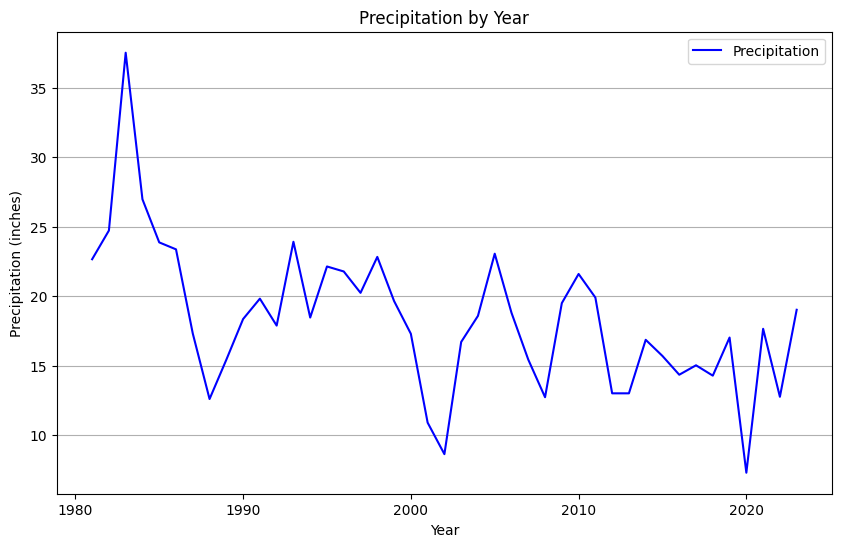

In [ ]:
#create a line plot using matplotlib of the annual precipitation data.
#All of this is just to make the plot match the hw
plt.figure(figsize=(10, 6))
plt.plot(byu_df.index, byu_df['Annual'], linestyle='-', color='b')
plt.title('Precipitation by Year')
plt.xlabel('Year')
plt.ylabel('Precipitation (inches)')
plt.legend(['Precipitation'])
plt.grid(axis='y')
plt.show()

In [ ]:
#Create three new dataframes (min_rain_df, max_rain_df, avg_rain_df) that contain the minimum, maximum, and average annual precipitation for each month over the entire dataset.
#three dataframes created, then put into the new dataframe
min_rain_df = byu_df.min()
max_rain_df = byu_df.max()
avg_rain_df = byu_df.mean()
stats_df = pd.DataFrame({'Min': min_rain_df, 'Max': max_rain_df, 'Average': avg_rain_df})
stats_df = stats_df.drop('Annual') #this is removes the annual column
stats_df

,Min,Max,Average
Jan,0.21,5.39,1.884651
Feb,0.06,4.50,1.679302
Mar,0.20,3.61,1.807827
Apr,0.11,4.69,1.789222
May,0.15,5.17,1.939070
Jun,0.00,4.14,0.963721
Jul,0.00,2.80,0.670465
Aug,0.00,4.38,0.999826
Sep,0.00,6.53,1.366118
Oct,0.05,5.05,1.798140


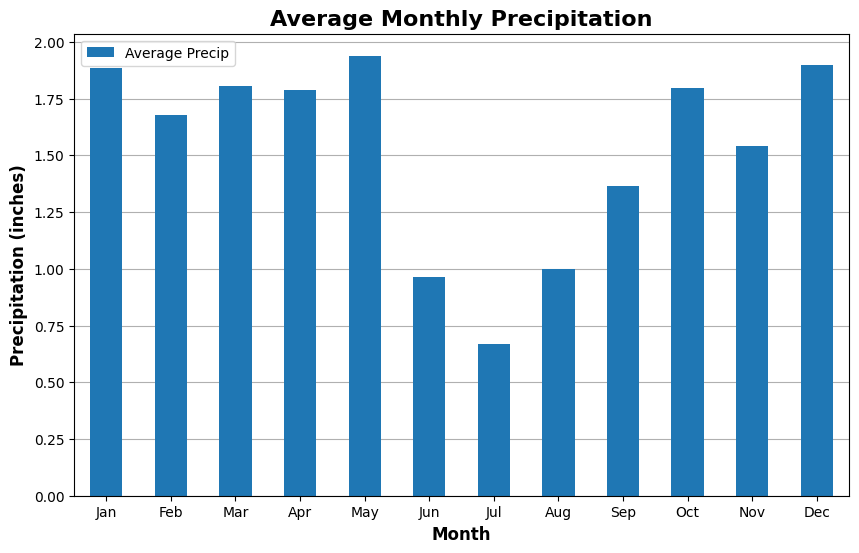

In [ ]:
#Plot the Avg column of the stats_df dataframe using a bar or a line chart using matplotlib.
#once again, just to make the plot match the hw
avg_rain_df.iloc[:-1].plot(kind='bar', figsize=(10, 6))
plt.title('Average Monthly Precipitation', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 12, fontweight = 'bold')
plt.ylabel('Precipitation (inches)', fontsize = 12, fontweight = 'bold')
plt.legend(['Average Precip'])
plt.grid(axis='y')
plt.gca().set_axisbelow(True)
plt.xticks(rotation=0)
plt.show()



In [94]:
###Export the Precip Data to Excel

In [ ]:
#This connects to the excel writer file thing
writer = pd.ExcelWriter('precip_summary.xlsx', engine='xlsxwriter')
#this writes the specific dataframe to the excel file
byu_df.to_excel(writer, sheet_name='Data')
#this creates a new work book and worksheet and names the worksheet
workbook = writer.book
worksheet = writer.sheets['Data']
#this creates a format to be used with the data
data_format = workbook.add_format({'align': 'center'})
worksheet.set_column('A:M', 8, data_format)
#this is the actual chart/line graph
chart1 = workbook.add_chart({'type': 'scatter', 'subtype': 'smooth'})
#these are variables to make the chart work, it gets the rows and columns
num_rows = len(byu_df)
annual_col = byu_df.columns.get_loc('Annual') + 1
#this is more of the graph data, including the rows and columns
chart1.add_series({
    'name': 'Precipitation',
    'categories': ['Data', 1, 0, num_rows, 0],
    'values': ['Data', 1, annual_col, num_rows, annual_col],
})
#this just names the graph and the axes
chart1.set_title({'name': 'Precipitation by Year'})
chart1.set_x_axis({'name': 'Year'})
chart1.set_y_axis({'name': 'Precipitation (inches)'})

#this is how the graph gets placed correctly into the excel file
worksheet.insert_chart('P2', chart1)

#this adds the second info to the excel
stats_df.to_excel(writer, index=True, sheet_name='Stats')
worksheet_stats = writer.sheets['Stats']

num_col_stats = len(stats_df.columns) + 1
col_range_stats = f'A:{chr(64 + num_col_stats)}'
worksheet_stats.set_column(col_range_stats, 8, data_format)

#this adds the second graph to the excel. this time a column graph
monthly_avg_df = avg_rain_df.iloc[:-1]

chart2 = workbook.add_chart({'type': 'column'})
chart2.add_series({
    'name': 'Average Monthly Precipitation',
    'categories': ['Stats', 1, 0, len(monthly_avg_df), 0],
    'values': ['Stats', 1, 3, len(monthly_avg_df), 3],
})
chart2.set_title({'name': 'Average Monthly Precipitation'})
chart2.set_x_axis({'name': 'Month'})
chart2.set_y_axis({'name': 'Precipitation (inches)'})
worksheet_stats.insert_chart('F2', chart2)    


0

In [ ]:
#here is just the sizing and closing of the workbook
workbook.set_size(2400, 1400)
workbook.close()